<a href="https://colab.research.google.com/github/Sravani3234/Infosys-Project/blob/main/ML_Driven_Web_Platform_for_Cryptocurrency_Price_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pandas numpy scikit-learn requests


In [ ]:
import os
import pandas as pd
import numpy as np
import requests
import time
from sklearn.preprocessing import MinMaxScaler

# --------------------------
# 1️⃣ Fetch Binance daily data
# --------------------------
def fetch_binance_data(symbol="BTCUSDT", interval="1d", limit=2000):
    os.makedirs("data", exist_ok=True)
    url = "https://api.binance.com/api/v3/klines"
    params = {"symbol": symbol, "interval": interval, "limit": limit}
    response = requests.get(url, params=params)
    data = response.json()

    df = pd.DataFrame(data, columns=[
        "open_time","open","high","low","close","volume",
        "close_time","quote_asset_volume","number_of_trades",
        "taker_buy_base_asset_volume","taker_buy_quote_asset_volume","ignore"
    ])

    df["timestamp"] = pd.to_datetime(df["open_time"], unit="ms", errors="coerce")
    df["price"] = pd.to_numeric(df["close"], errors="coerce")
    df["volume"] = pd.to_numeric(df["volume"], errors="coerce")

    df = df.dropna(subset=["timestamp","price","volume"])
    df["date"] = df["timestamp"].dt.floor("D")
    df = df[["date","price","volume"]]

    df.to_csv("data/binance_data.csv", index=False)
    print("Binance data saved to data/binance_data.csv")
    return df

# --------------------------
# 2️⃣ Fetch CoinGecko daily market cap
# --------------------------
def fetch_coingecko_data(coin_id="bitcoin", vs_currency="usd", total_days=730):
    all_df = pd.DataFrame()
    chunk_size = 365
    for start_day in range(0, total_days, chunk_size):
        days = min(chunk_size, total_days - start_day)
        url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
        params = {"vs_currency": vs_currency, "days": days, "interval": "daily"}
        response = requests.get(url, params=params)
        if response.status_code != 200:
            print(f"Warning: API request failed with status {response.status_code}")
            continue
        data = response.json()
        if "market_caps" not in data:
            print("Warning: 'market_caps' missing, skipping chunk")
            continue

        df_chunk = pd.DataFrame({
            "timestamp": [pd.to_datetime(p[0], unit='ms', errors="coerce") for p in data["market_caps"]],
            "market_cap": [p[1] for p in data["market_caps"]]
        })
        df_chunk = df_chunk.dropna(subset=["timestamp","market_cap"])
        all_df = pd.concat([all_df, df_chunk])
        time.sleep(1)

    if all_df.empty:
        raise ValueError("No market cap data fetched")

    all_df["date"] = all_df["timestamp"].dt.floor("D")
    all_df = all_df.groupby("date")[["market_cap"]].mean().reset_index()

    os.makedirs("data", exist_ok=True)
    all_df.to_csv("data/coingecko_data.csv", index=False)
    print("CoinGecko data saved to data/coingecko_data.csv")
    return all_df

# --------------------------
# 3️⃣ Preprocess & merge safely (resample fallback)
# --------------------------
def preprocess_data_safe(binance_path="data/binance_data.csv",
                         coingecko_path="data/coingecko_data.csv",
                         output_path="data/processed_data.csv"):

    df_bin = pd.read_csv(binance_path)
    df_geo = pd.read_csv(coingecko_path)

    df_bin["date"] = pd.to_datetime(df_bin["date"], errors="coerce")
    df_geo["date"] = pd.to_datetime(df_geo["date"], errors="coerce")

    df_bin = df_bin.dropna(subset=["date","price","volume"]).set_index("date").resample("D").mean()
    df_geo = df_geo.dropna(subset=["date","market_cap"]).set_index("date").resample("D").mean()

    # Merge on date
    df = pd.merge(df_bin, df_geo, left_index=True, right_index=True, how="outer")

    # Fill missing values
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    if df.empty:
        raise ValueError("No data after merge! Something went wrong with fetch.")

    # Normalize
    scaler = MinMaxScaler()
    df[["price","volume","market_cap"]] = scaler.fit_transform(df[["price","volume","market_cap"]])

    df.reset_index(inplace=True)
    os.makedirs("data", exist_ok=True)
    df.to_csv(output_path, index=False)
    print("Processed data saved to", output_path)
    return df

# --------------------------
# 4️⃣ Time-series split
# --------------------------
def create_time_series_dataset(input_path="data/processed_data.csv", window_size=30):
    df = pd.read_csv(input_path)

    X, y = [], []
    for i in range(len(df) - window_size):
        X.append(df[["price","volume","market_cap"]].iloc[i:i+window_size].values)
        y.append(df["price"].iloc[i+window_size])

    X, y = np.array(X), np.array(y)

    train_size = int(0.7*len(X))
    val_size = int(0.15*len(X))

    X_train, y_train = X[:train_size], y[:train_size]
    X_val, y_val = X[train_size:train_size+val_size], y[train_size:train_size+val_size]
    X_test, y_test = X[train_size+val_size:], y[train_size+val_size:]

    os.makedirs("data/train_val_test", exist_ok=True)
    np.save("data/train_val_test/X_train.npy", X_train)
    np.save("data/train_val_test/y_train.npy", y_train)
    np.save("data/train_val_test/X_val.npy", X_val)
    np.save("data/train_val_test/y_val.npy", y_val)
    np.save("data/train_val_test/X_test.npy", X_test)
    np.save("data/train_val_test/y_test.npy", y_test)

    print("Train/Val/Test datasets saved in data/train_val_test/")
    return X_train, y_train, X_val, y_val, X_test, y_test

# --------------------------
# 5️⃣ Run full pipeline
# --------------------------
if __name__ == "__main__":
    print("Fetching Binance data...")
    df_bin = fetch_binance_data(limit=2000)

    print("Fetching CoinGecko data...")
    df_geo = fetch_coingecko_data(total_days=730)

    print("Preprocessing & merging data...")
    df_processed = preprocess_data_safe()

    print("Creating time-series datasets...")
    X_train, y_train, X_val, y_val, X_test, y_test = create_time_series_dataset()

    print("Pipeline completed successfully!")
    print("Shapes:")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:", X_val.shape, "y_val:", y_val.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)


Fetching Binance data...
Binance data saved to data/binance_data.csv
Fetching CoinGecko data...
CoinGecko data saved to data/coingecko_data.csv
Preprocessing & merging data...
Processed data saved to data/processed_data.csv
Creating time-series datasets...


/tmp/ipython-input-4106751380.py:94: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.ffill(inplace=True)
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:776: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmin(X, axis=axis))
/usr/local/lib/python3.12/dist-packages/sklearn/utils/_array_api.py:793: RuntimeWarning: All-NaN slice encountered
  return xp.asarray(numpy.nanmax(X, axis=axis))


Train/Val/Test datasets saved in data/train_val_test/
Pipeline completed successfully!
Shapes:
X_train: (234, 30, 3) y_train: (234,)
X_val: (50, 30, 3) y_val: (50,)
X_test: (51, 30, 3) y_test: (51,)


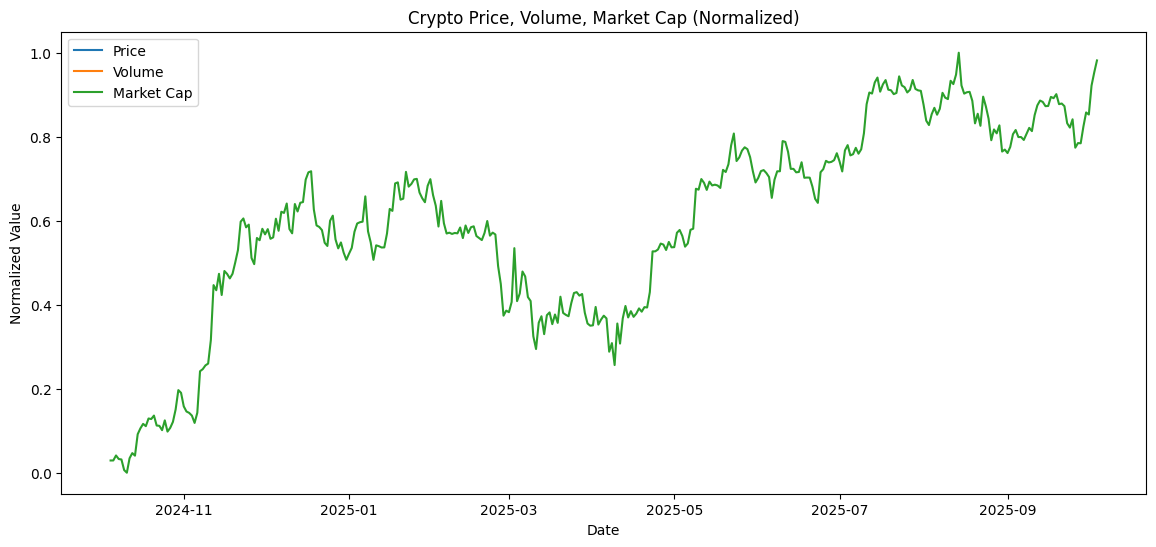

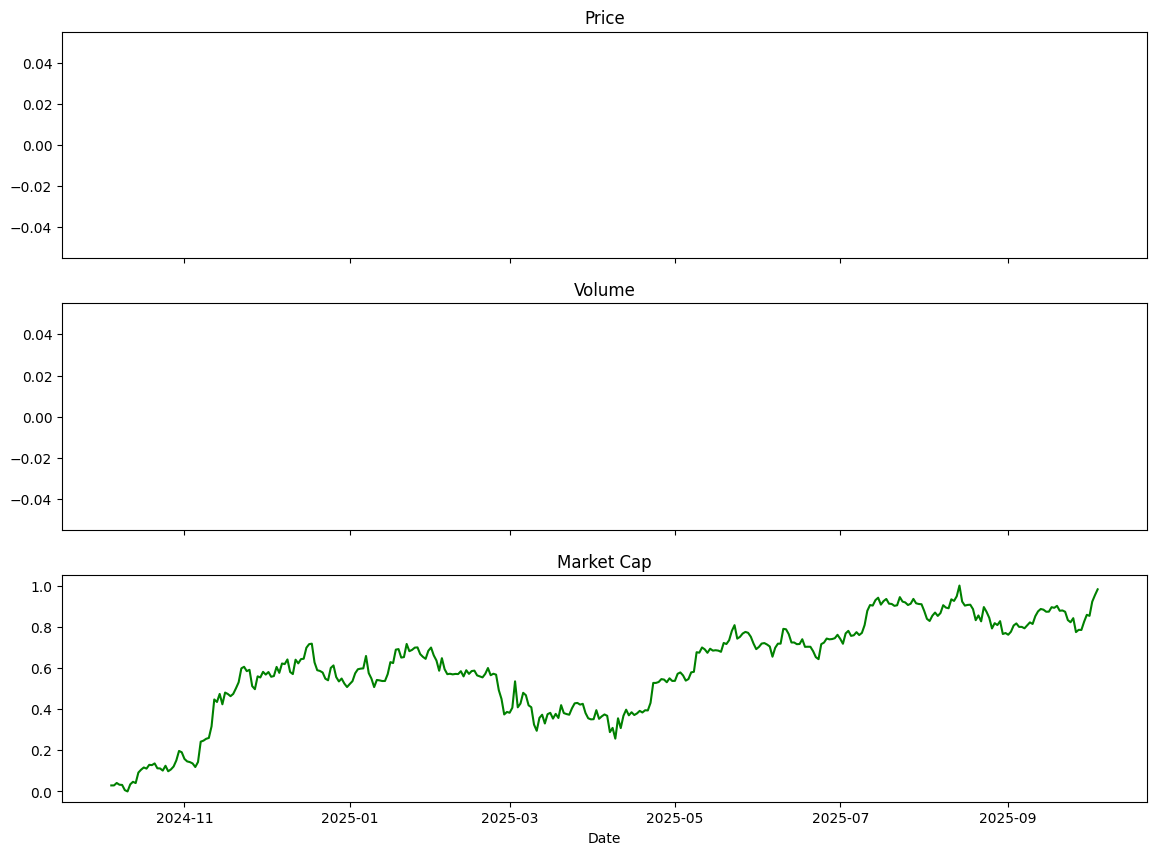

In [ ]:
import matplotlib.pyplot as plt

# Read the processed data
df = pd.read_csv("data/processed_data.csv", parse_dates=["date"])

# Plot price, volume, market cap
plt.figure(figsize=(14,6))
plt.plot(df["date"], df["price"], label="Price")
plt.plot(df["date"], df["volume"], label="Volume")
plt.plot(df["date"], df["market_cap"], label="Market Cap")
plt.title("Crypto Price, Volume, Market Cap (Normalized)")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.legend()
plt.show()

# Optional: Separate plots for clarity
fig, ax = plt.subplots(3,1, figsize=(14,10), sharex=True)
ax[0].plot(df["date"], df["price"], color="blue"); ax[0].set_title("Price")
ax[1].plot(df["date"], df["volume"], color="orange"); ax[1].set_title("Volume")
ax[2].plot(df["date"], df["market_cap"], color="green"); ax[2].set_title("Market Cap")
plt.xlabel("Date")
plt.show()


In [ ]:
pip install pandas numpy matplotlib scikit-learn

Initial Model Performance:
MSE: 0.1110, MAE: 0.2645, RMSE: 0.3332

Best Params: {'n_estimators': 500, 'min_samples_split': 10, 'max_depth': None}

Tuned Model Performance:
MSE: 0.1069, MAE: 0.2602, RMSE: 0.3269


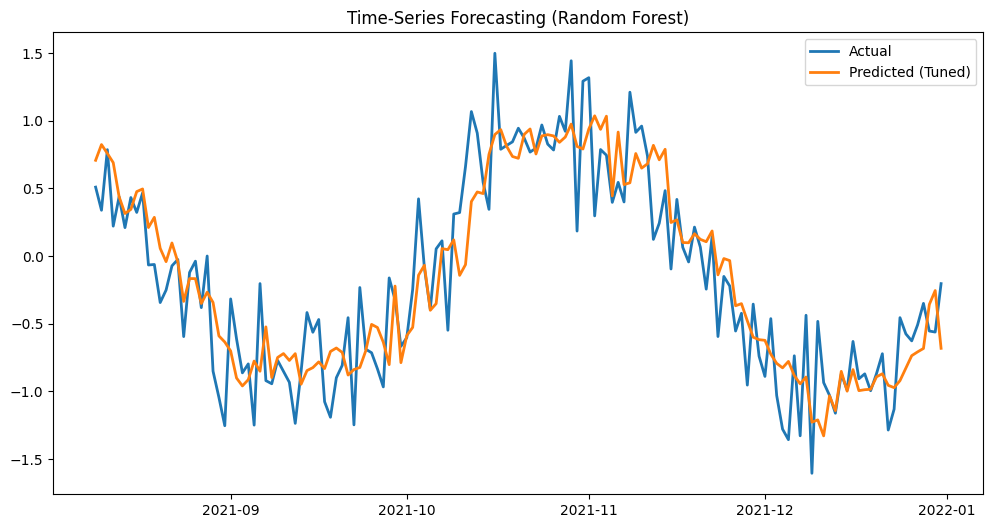

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV

# ----------------------------
# 1. Generate Synthetic Time-Series Data
# ----------------------------
np.random.seed(42)
date_rng = pd.date_range(start='2020-01-01', end='2021-12-31', freq='D')
data = np.sin(np.linspace(0, 50, len(date_rng))) + np.random.normal(0, 0.3, len(date_rng))

df = pd.DataFrame(date_rng, columns=['date'])
df['value'] = data
df.set_index('date', inplace=True)

# ----------------------------
# 2. Feature Engineering
# ----------------------------
df['lag_1'] = df['value'].shift(1)
df['lag_7'] = df['value'].shift(7)
df['rolling_mean_7'] = df['value'].rolling(window=7).mean()
df['rolling_std_7'] = df['value'].rolling(window=7).std()
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek

df = df.dropna()  # drop rows with NaN from shifting/rolling

# ----------------------------
# 3. Train-Test Split
# ----------------------------
X = df.drop('value', axis=1)
y = df['value']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# ----------------------------
# 4. Train Model (Random Forest)
# ----------------------------
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# ----------------------------
# 5. Evaluation
# ----------------------------
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("Initial Model Performance:")
print(f"MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

# ----------------------------
# 6. Hyperparameter Tuning
# ----------------------------
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10]
}

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=5,
    cv=3,
    scoring='neg_mean_absolute_error',
    random_state=42
)

search.fit(X_train, y_train)
best_model = search.best_estimator_

print("\nBest Params:", search.best_params_)

# ----------------------------
# 7. Evaluate Best Model
# ----------------------------
y_pred_best = best_model.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)

print("\nTuned Model Performance:")
print(f"MSE: {mse_best:.4f}, MAE: {mae_best:.4f}, RMSE: {rmse_best:.4f}")

# ----------------------------
# 8. Plot Actual vs Predicted
# ----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label="Actual", linewidth=2)
plt.plot(y_test.index, y_pred_best, label="Predicted (Tuned)", linewidth=2)
plt.legend()
plt.title("Time-Series Forecasting (Random Forest)")
plt.show()


/tmp/ipython-input-3327448541.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BTC-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Bitcoin - MSE: 5542926.97, MAE: 1835.93, RMSE: 2354.34


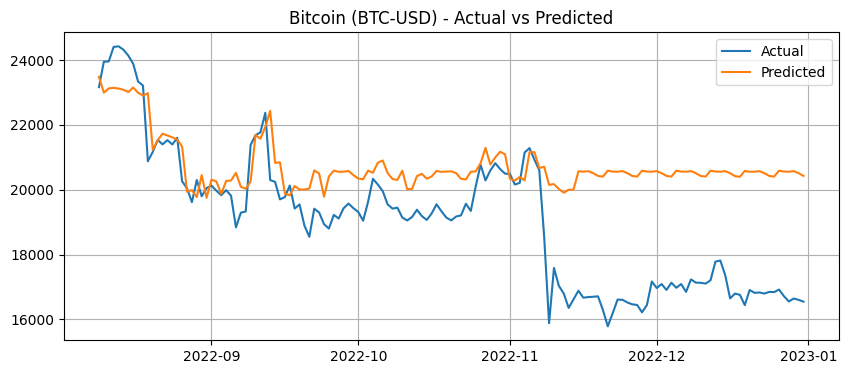

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = yf.download("BTC-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
df.dropna(inplace=True)

# Feature Engineering
df['lag_1'] = df['value'].shift(1)
df['lag_7'] = df['value'].shift(7)
df['rolling_mean_7'] = df['value'].rolling(7).mean()
df['rolling_std_7'] = df['value'].rolling(7).std()
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df.dropna(inplace=True)

X = df.drop('value', axis=1)
y = df['value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Bitcoin - MSE: {mse:.2f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.title("Bitcoin (BTC-USD) - Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-1601130873.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("ETH-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Ethereum - MSE: 8337.02, MAE: 71.85, RMSE: 91.31


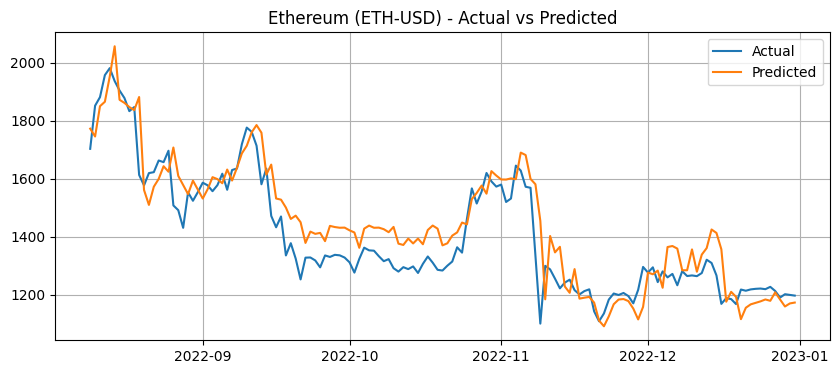

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = yf.download("ETH-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
df.dropna(inplace=True)

df['lag_1'] = df['value'].shift(1)
df['lag_7'] = df['value'].shift(7)
df['rolling_mean_7'] = df['value'].rolling(7).mean()
df['rolling_std_7'] = df['value'].rolling(7).std()
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df.dropna(inplace=True)

X = df.drop('value', axis=1)
y = df['value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Ethereum - MSE: {mse:.2f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.title("Ethereum (ETH-USD) - Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-3097607926.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("BNB-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Binance Coin - MSE: 120.67, MAE: 7.56, RMSE: 10.98


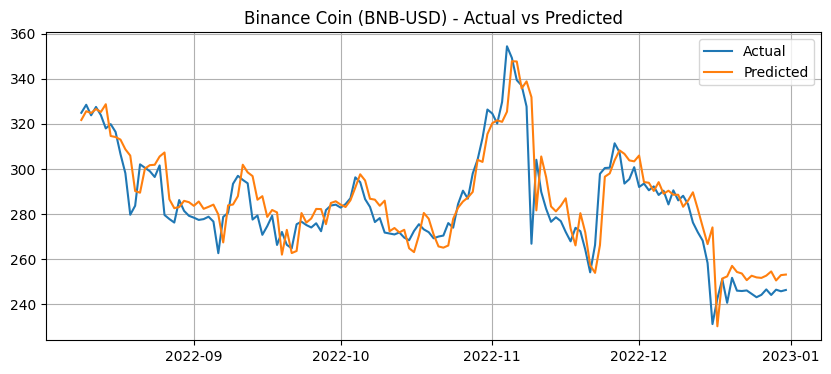

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = yf.download("BNB-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
df.dropna(inplace=True)

df['lag_1'] = df['value'].shift(1)
df['lag_7'] = df['value'].shift(7)
df['rolling_mean_7'] = df['value'].rolling(7).mean()
df['rolling_std_7'] = df['value'].rolling(7).std()
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df.dropna(inplace=True)

X = df.drop('value', axis=1)
y = df['value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Binance Coin - MSE: {mse:.2f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.title("Binance Coin (BNB-USD) - Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-4147507513.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("ADA-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Cardano - MSE: 0.00, MAE: 0.04, RMSE: 0.04


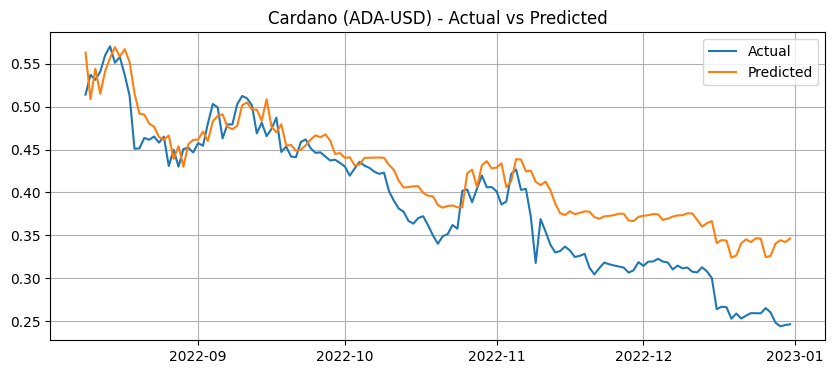

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = yf.download("ADA-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
df.dropna(inplace=True)

df['lag_1'] = df['value'].shift(1)
df['lag_7'] = df['value'].shift(7)
df['rolling_mean_7'] = df['value'].rolling(7).mean()
df['rolling_std_7'] = df['value'].rolling(7).std()
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df.dropna(inplace=True)

X = df.drop('value', axis=1)
y = df['value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Cardano - MSE: {mse:.2f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.title("Cardano (ADA-USD) - Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-3725037710.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("XRP-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Ripple - MSE: 0.00, MAE: 0.02, RMSE: 0.02


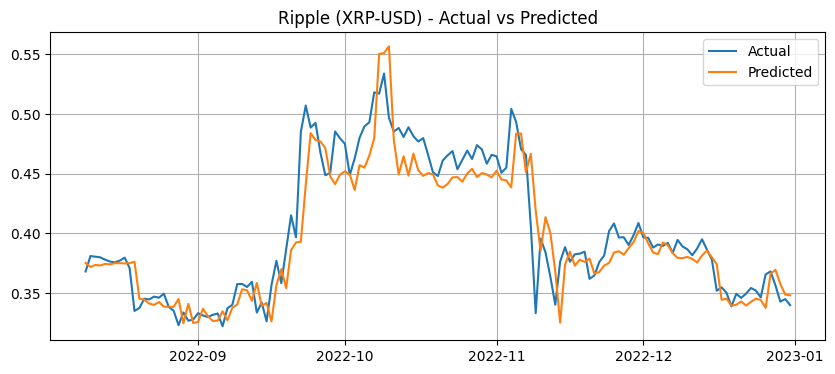

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = yf.download("XRP-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
df.dropna(inplace=True)

df['lag_1'] = df['value'].shift(1)
df['lag_7'] = df['value'].shift(7)
df['rolling_mean_7'] = df['value'].rolling(7).mean()
df['rolling_std_7'] = df['value'].rolling(7).std()
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df.dropna(inplace=True)

X = df.drop('value', axis=1)
y = df['value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Ripple - MSE: {mse:.2f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.title("Ripple (XRP-USD) - Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-1565178708.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("SOL-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Solana - MSE: 6.71, MAE: 1.69, RMSE: 2.59


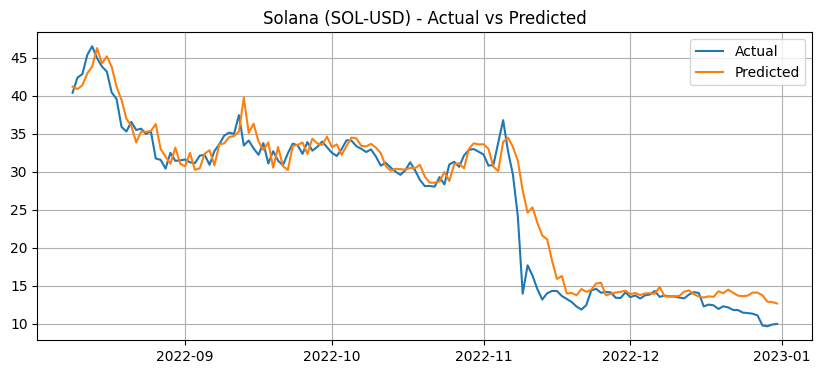

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error

df = yf.download("SOL-USD", start="2021-01-01", end="2023-01-01")[['Close']].rename(columns={'Close': 'value'})
df.dropna(inplace=True)

df['lag_1'] = df['value'].shift(1)
df['lag_7'] = df['value'].shift(7)
df['rolling_mean_7'] = df['value'].rolling(7).mean()
df['rolling_std_7'] = df['value'].rolling(7).std()
df['month'] = df.index.month
df['dayofweek'] = df.index.dayofweek
df.dropna(inplace=True)

X = df.drop('value', axis=1)
y = df['value']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

print(f"Solana - MSE: {mse:.2f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

plt.figure(figsize=(10,4))
plt.plot(y_test.index, y_test, label="Actual")
plt.plot(y_test.index, y_pred, label="Predicted")
plt.title("Solana (SOL-USD) - Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


/tmp/ipython-input-3325185263.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


Mean Squared Error: 1984253816.68


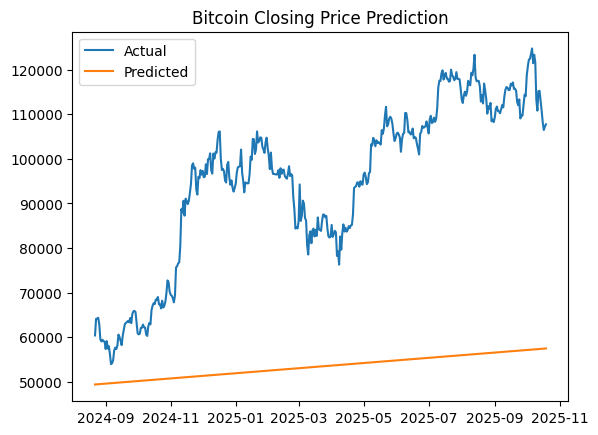

In [ ]:
# Program 1: Predicting Bitcoin Closing Price
!pip install yfinance scikit-learn matplotlib

import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load data
btc = yf.download("BTC-USD", start="2020-01-01")
X = np.arange(len(btc)).reshape(-1, 1)
y = btc["Close"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Model
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)

# Evaluate
mse = mean_squared_error(y_test, pred)
print(f"Mean Squared Error: {mse:.2f}")

# Plot
plt.plot(btc.index[-len(X_test):], y_test, label="Actual")
plt.plot(btc.index[-len(X_test):], pred, label="Predicted")
plt.legend(); plt.title("Bitcoin Closing Price Prediction"); plt.show()


/tmp/ipython-input-942455250.py:11: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Volume Prediction MSE: 975720101827049947136.00


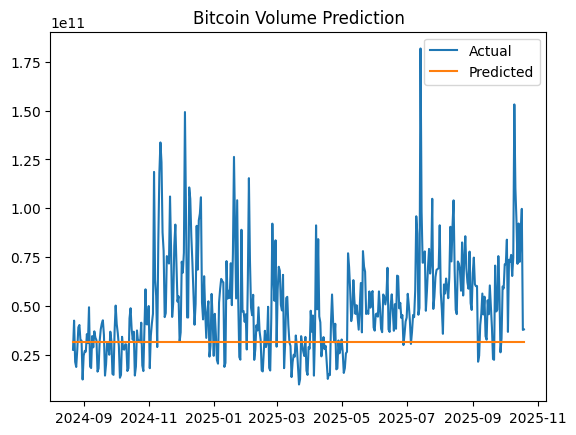

In [ ]:
# Program 2: Predicting Bitcoin Trading Volume
!pip install yfinance scikit-learn matplotlib

import yfinance as yf
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

btc = yf.download("BTC-USD", start="2020-01-01")

X = np.arange(len(btc)).reshape(-1, 1)
y = btc["Volume"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

mse = mean_squared_error(y_test, pred)
print(f"Volume Prediction MSE: {mse:.2f}")

plt.plot(btc.index[-len(X_test):], y_test, label="Actual")
plt.plot(btc.index[-len(X_test):], pred, label="Predicted")
plt.title("Bitcoin Volume Prediction"); plt.legend(); plt.show()


/tmp/ipython-input-2376369504.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


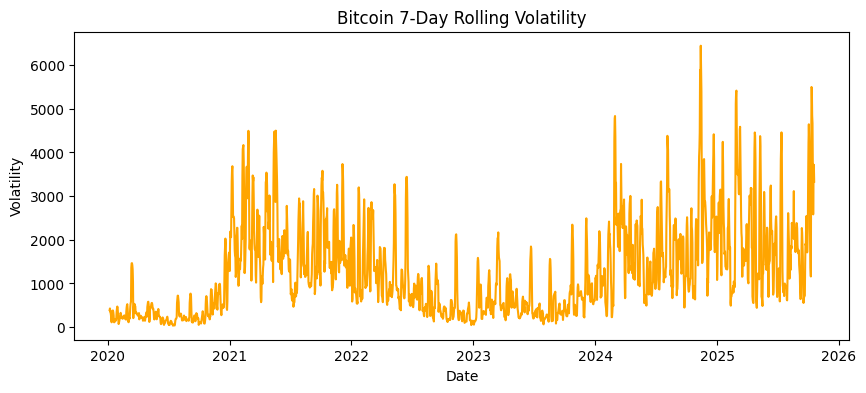

Average Volatility: 1274.80


In [ ]:
# Program 3: Volatility Estimation
!pip install yfinance matplotlib pandas

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

btc = yf.download("BTC-USD", start="2020-01-01")
btc["Volatility"] = btc["Close"].rolling(window=7).std()

plt.figure(figsize=(10,4))
plt.plot(btc.index, btc["Volatility"], color='orange')
plt.title("Bitcoin 7-Day Rolling Volatility")
plt.xlabel("Date"); plt.ylabel("Volatility"); plt.show()

print(f"Average Volatility: {btc['Volatility'].mean():.2f}")


/tmp/ipython-input-1476360209.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


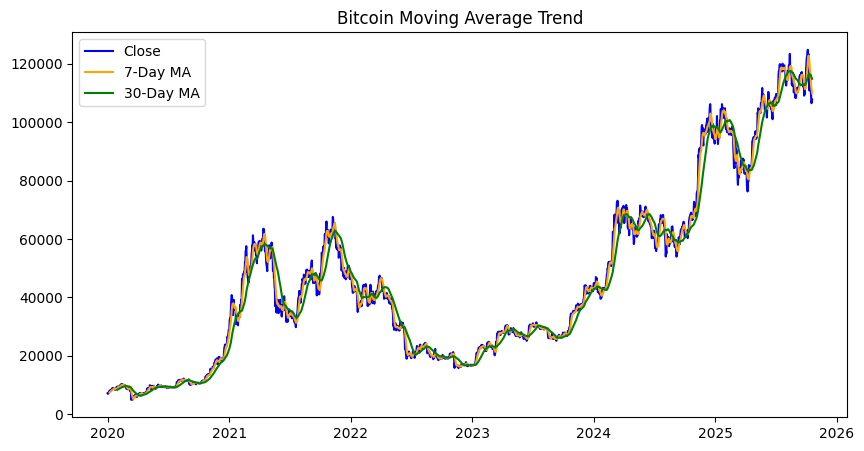

In [ ]:
# Program 4: Moving Average Trend
!pip install yfinance matplotlib pandas

import yfinance as yf
import matplotlib.pyplot as plt

btc = yf.download("BTC-USD", start="2020-01-01")
btc["MA7"] = btc["Close"].rolling(7).mean()
btc["MA30"] = btc["Close"].rolling(30).mean()

plt.figure(figsize=(10,5))
plt.plot(btc["Close"], label="Close", color='blue')
plt.plot(btc["MA7"], label="7-Day MA", color='orange')
plt.plot(btc["MA30"], label="30-Day MA", color='green')
plt.title("Bitcoin Moving Average Trend")
plt.legend(); plt.show()


In [ ]:
# Program 5: Predicting Next-Day Trend (Up or Down)
!pip install yfinance scikit-learn matplotlib pandas

import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

btc = yf.download("BTC-USD", start="2020-01-01")

btc["Target"] = np.where(btc["Close"].shift(-1) > btc["Close"], 1, 0)
features = ["Open", "High", "Low", "Close", "Volume"]

X = btc[features].fillna(0)
y = btc["Target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, shuffle=False)

svc = SVC(kernel='rbf', gamma='scale')
svc.fit(X_train, y_train)
pred = svc.predict(X_test)

acc = accuracy_score(y_test, pred)
print(f"Trend Direction Accuracy: {acc*100:.2f}%")


/tmp/ipython-input-2796058046.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


Trend Direction Accuracy: 48.35%


/tmp/ipython-input-1914700562.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  btc = yf.download("BTC-USD", start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


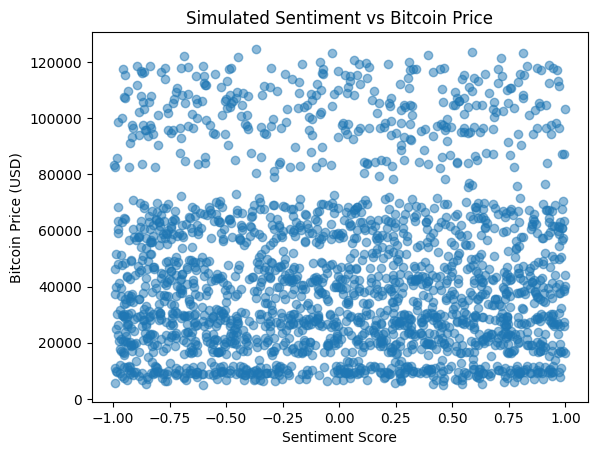

ValueError: all the input array dimensions except for the concatenation axis must match exactly, but along dimension 1, the array at index 0 has size 2119 and the array at index 1 has size 1

In [ ]:
# Program 6: Simulated Sentiment Score vs Bitcoin Price
!pip install yfinance matplotlib pandas numpy

import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

btc = yf.download("BTC-USD", start="2020-01-01")

# Simulate sentiment score (-1 = negative, +1 = positive)
np.random.seed(42)
btc["Sentiment_Score"] = np.random.uniform(-1, 1, len(btc))

plt.scatter(btc["Sentiment_Score"], btc["Close"], alpha=0.5)
plt.title("Simulated Sentiment vs Bitcoin Price")
plt.xlabel("Sentiment Score"); plt.ylabel("Bitcoin Price (USD)")
plt.show()

corr = btc["Sentiment_Score"].corr(btc["Close"])
print(f"Correlation between Sentiment and Price: {corr:.3f}")
